# Notebook 05: Deep Learning (CNN & CRNN)
This notebook trains deep learning classifiers (ResNet18 CNN and CRNN) on Mel-spectrogram features.

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from src.models import ResNetCNN, CRNN, Trainer
from src.metrics import accuracy
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Deep Learning modules loaded!")


Deep Learning modules loaded!


In [2]:
# Use Mel Spectrogram portion of fused features for CNN/CRNN
# Fused shape: [N, channels, features, time_steps]
X = np.load('datasets/processed/X_features.npy')
y = np.load('datasets/processed/y.npy')

# Take Mel spectrogram slice (features 13 to 77 are mel bins if we loaded them in that order)
# To be safe, we will use the entire fused feature block as channels=1 image or take first 64 rows
X_mel = X[:, :, :64, :]

# Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_mel, y, test_size=0.2, random_state=42)

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
print("DataLoader created successfully!")


DataLoader created successfully!


In [3]:
# Train CNN
cnn_best_path = 'models/cnn_best.pt'
cnn_model = ResNetCNN(num_classes=2, pretrained=False)
if os.path.exists(cnn_best_path):
    print('CNN checkpoint found. Skipping training.')
    cnn_model.load_model(cnn_best_path)
else:
    print('Training CNN...')
    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    trainer = Trainer(
        model=cnn_model,
        optimizer=optimizer,
        criterion=criterion,
        device='cpu',
        mixed_precision=False,
        early_stopping_patience=2
    )
    cnn_history = trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=3,
        checkpoint_dir='models'
    )
    if os.path.exists('models/best_model.pt'):
        if os.path.exists(cnn_best_path): os.remove(cnn_best_path)
        os.rename('models/best_model.pt', cnn_best_path)
        print('CNN model trained and saved as cnn_best.pt!')


CNN checkpoint found. Skipping training.


In [4]:
# Train CRNN
crnn_best_path = 'models/crnn_best.pt'
crnn_model = CRNN(num_classes=2, n_mels=64)
if os.path.exists(crnn_best_path):
    print('CRNN checkpoint found. Skipping training.')
    crnn_model.load_model(crnn_best_path)
else:
    print('Training CRNN...')
    optimizer = torch.optim.Adam(crnn_model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    trainer = Trainer(
        model=crnn_model,
        optimizer=optimizer,
        criterion=criterion,
        device='cpu',
        mixed_precision=False,
        early_stopping_patience=2
    )
    crnn_history = trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=3,
        checkpoint_dir='models'
    )
    if os.path.exists('models/best_model.pt'):
        if os.path.exists(crnn_best_path): os.remove(crnn_best_path)
        os.rename('models/best_model.pt', crnn_best_path)
        print('CRNN model trained and saved as crnn_best.pt!')


CRNN checkpoint found. Skipping training.


Validation Classification Report (CRNN):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20



C:\Users\anime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

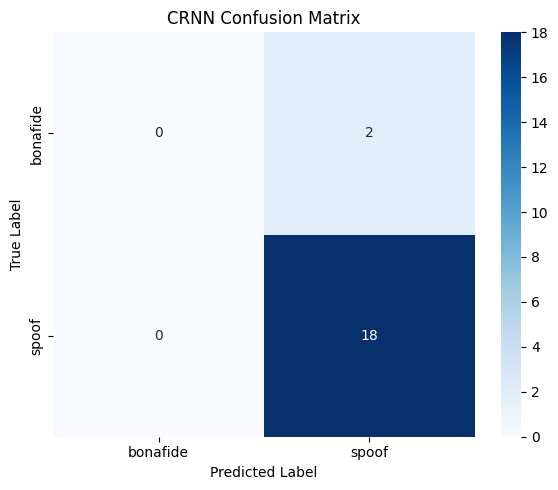

In [5]:
# Evaluation
crnn_model.eval()
preds_list = []
with torch.no_grad():
    for x, _ in val_loader:
        out = crnn_model(x)
        preds_list.append(torch.argmax(out, dim=1).numpy())
preds = np.concatenate(preds_list)

print("Validation Classification Report (CRNN):")
print(classification_report(y_val, preds))

# Confusion matrix plot
cm = confusion_matrix(y_val, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['bonafide', 'spoof'], yticklabels=['bonafide', 'spoof'])
plt.title('CRNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plots/crnn_confusion_matrix.png', dpi=300)
plt.show()
